# 002 · Bloque 2D relleno vs muro 1D homogéneo

Si la cavidad de un `HollowBlock` se rellena con el **mismo material** de la
cáscara, el bloque se vuelve sólido y debe reproducir un muro 1D homogéneo del
mismo espesor. Aquí comparamos la `Ti` de ambos sistemas: deben salir iguales.

In [1]:
import enerhabitat as eh
import matplotlib.pyplot as plt

eh.config.file = "materials.ini"
epw_file = "../epw/Temixco_2018CST.epw"

MATERIAL = "Concreto"
GEOMETRY = {
    "web": 0.02, "block_width": 0.16,
    "cover_top": 0.04, "cavity": 0.12, "cover_bottom": 0.04,
}

In [2]:
# Bloque 2D con la cavidad rellena del mismo material -> sólido
block = eh.HollowBlock(
    material      = MATERIAL,
    fill_type     = eh.Fill.SOLID,          # relleno sólido en vez de aire
    fill_material = MATERIAL,                # mismo material que la cáscara
    geometry      = GEOMETRY,
)

wall_2d = eh.System2D(eh.Location(epw_file))
wall_2d.tilt = 90
wall_2d.azimuth = 90
wall_2d.absortance = 0.6
wall_2d.layers = [block]
wall_2d.location.meanDay(month=5, year=2025)
wall_2d.Tsa()

Ti_2d = wall_2d.solve()

In [5]:
# Muro 1D homogéneo del mismo espesor (cover_top + cavity + cover_bottom = 0.20 m)
wall_1d = eh.System(eh.Location(epw_file))
wall_1d.tilt = 90
wall_1d.azimuth = 90
wall_1d.absortance = 0.6
wall_1d.layers = [(MATERIAL, block.thickness)]
wall_1d.location.meanDay(month=5, year=2025)
wall_1d.Tsa()

Ti_1d = wall_1d.solve()

In [6]:
Ti_1d

2025-05-15 00:00:00-06:00    35.435364
2025-05-15 00:00:10-06:00    35.433919
2025-05-15 00:00:20-06:00    35.432473
2025-05-15 00:00:30-06:00    35.431027
2025-05-15 00:00:40-06:00    35.429581
                               ...    
2025-05-15 23:58:20-06:00    35.442691
2025-05-15 23:58:30-06:00    35.441249
2025-05-15 23:58:40-06:00    35.439806
2025-05-15 23:58:50-06:00    35.438362
2025-05-15 23:59:00-06:00    35.436919
Freq: 10s, Name: Ti, Length: 8635, dtype: float64

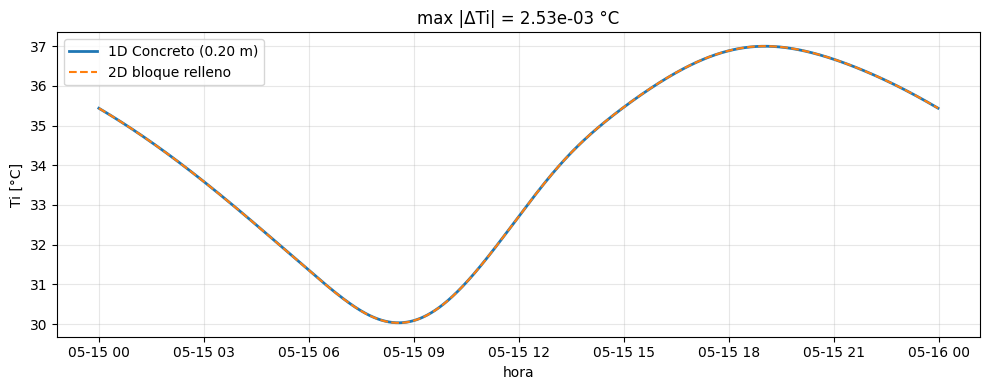

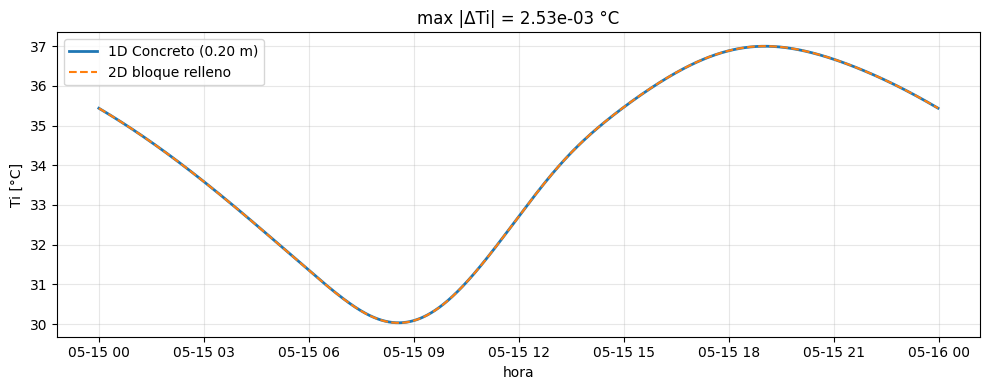

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(Ti_1d.index, Ti_1d, lw=2, label=f"1D {MATERIAL} ({block.thickness:.2f} m)")
ax.plot(Ti_2d.index, Ti_2d, "--", lw=1.5, label="2D bloque relleno")
ax.set_xlabel("hora")
ax.set_ylabel("Ti [°C]")
ax.set_title(f"max |ΔTi| = {(Ti_2d - Ti_1d).abs().max():.2e} °C")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig